# 7.4.2 无迹变换与后验形状

## 学习目标与先修知识

构造确定性采样（sampling）点，比较UKF矩近似、EKF与低维积分后验（posterior）。

先修：7.4.1的EKF及7.3.1的Gaussian矩。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

不用求导，而把少数代表点穿过非线性函数，能保留哪些信息？又有哪些后验形状即使矩计算得好也无法被一个Gaussian表达？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
m=.6;P=.8;points=np.array([m,m+np.sqrt(P),m-np.sqrt(P)])
print('三个点=',points,'平均平方=',.5*(points[1]**2+points[2]**2),'均值的平方=',m*m)

三个点= [ 0.6         1.49442719 -0.29442719] 平均平方= 1.16 均值的平方= 0.36


## 模型假设

无迹变换（unscented transform，UT）使用确定性sigma点（sigma point），不是随机抽样。本节n=1、alpha=1、beta=2、kappa=0。过程与测量加性噪声在对应矩传播后加入。与前节共享同一饱和转移、同一观测（observation）序列和噪声；一维网格作为有截断与离散误差的独立数值参照。

## 数学解释与推导

一般n维中，$\lambda=\alpha^2(n+\kappa)-n$；点为 $m$ 与 $m\pm[\sqrt{(n+\lambda)P}]_i$。
$$W_0^m=\frac\lambda{n+\lambda},\quad W_0^c=W_0^m+1-\alpha^2+\beta,\quad W_i^m=W_i^c=\frac1{2(n+\lambda)}.$$
本节三点权重分别为 $W^m=(0,1/2,1/2)$、$W^c=(2,1/2,1/2)$；协方差（covariance）权重不是概率（probability）。将点穿过h后计算
$$\bar y=\sum_iW_i^mh(\chi_i),\quad S=\sum_iW_i^c(h(\chi_i)-\bar y)^2+R,\quad C=\sum_iW_i^c(\chi_i-m)(h(\chi_i)-\bar y).$$
再用 $K=C/S$ 做Gaussian条件近似，得到无迹卡尔曼滤波（unscented Kalman filtering，UKF）。对高斯变量平方观测，解析矩为 $E[x^2]=m^2+P$、$\operatorname{Var}(x^2)=4m^2P+2P^2$、$\operatorname{Cov}(x,x^2)=2mP$，此权重恰好恢复它们。

但精确观测前矩不等于精确条件分布（distribution）。独立参照直接计算 $p(x\mid y)\propto\exp[-(x-m)^2/(2P)-(y-x^2)^2/(2R)]$；序列则按转移密度积分预测，再逐点乘似然（likelihood）。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型（model）与当时可用的信息。

In [3]:
def nonlinear_update(mean, variance, observation, measurement_variance, method='ekf'):
    if method == 'ekf':
        predicted_observation = mean ** 2
        cross = 2 * mean * variance
        innovation_variance = 4 * mean ** 2 * variance + measurement_variance
    elif method == 'ukf':
        # n=1, alpha=1,beta=2,kappa=0: Wm=(0,1/2,1/2), Wc=(2,1/2,1/2)。
        points = np.array([mean, mean + math.sqrt(variance), mean - math.sqrt(variance)])
        wm, wc = np.array([0., .5, .5]), np.array([2., .5, .5])
        transformed = points ** 2
        predicted_observation = float(wm @ transformed)
        cross = float(np.sum(wc * (points - mean) * (transformed - predicted_observation)))
        innovation_variance = float(np.sum(wc * (transformed - predicted_observation) ** 2) + measurement_variance)
    else:
        raise ValueError('method必须为ekf或ukf')
    gain = cross / innovation_variance
    return dict(mean=float(mean + gain * (observation - predicted_observation)),
                variance=float(variance - gain * cross), observation_mean=float(predicted_observation),
                innovation_variance=float(innovation_variance), cross_covariance=float(cross))


def saturating_step(state, step=.25, rate=.6, saturation_scale=1.0):
    """state和saturation_scale同为U；step*rate无量纲。"""
    return state - step * rate * state / (1 + np.abs(state) / saturation_scale)


def nonlinear_filter(initial_mean, initial_variance, process_variance, measurement_variance, observations, method):
    mean, variance = initial_mean, initial_variance
    saturation_scale = 1.0  # U，与状态单位相同。
    means, variances = [], []
    for t, observed in enumerate(observations):
        if t and method == 'ekf':
            derivative = 1 - .25 * .6 / (1 + abs(mean) / saturation_scale) ** 2
            mean, variance = saturating_step(mean, saturation_scale=saturation_scale), derivative ** 2 * variance + process_variance
        elif t:
            points = np.array([mean, mean + math.sqrt(variance), mean - math.sqrt(variance)])
            propagated = saturating_step(points, saturation_scale=saturation_scale)
            mean = float(np.array([0., .5, .5]) @ propagated)
            variance = float(np.array([2., .5, .5]) @ (propagated - mean) ** 2 + process_variance)
        if observed is not None:
            update = nonlinear_update(mean, variance, observed, measurement_variance, method)
            mean, variance = update['mean'], update['variance']
        means.append(float(mean)); variances.append(float(variance))
    return dict(means=means, variances=variances)


def grid_update(mean, variance, observation, measurement_variance, lower=-6, upper=6, count=6001):
    grid = np.linspace(lower, upper, count)
    log_mass = -.5 * ((grid - mean) ** 2 / variance + (observation - grid ** 2) ** 2 / measurement_variance)
    mass = np.exp(log_mass - log_mass.max())
    density = mass / np.trapezoid(mass, grid)
    updated_mean = float(np.trapezoid(grid * density, grid))
    updated_variance = float(np.trapezoid((grid - updated_mean) ** 2 * density, grid))
    return grid, density, updated_mean, updated_variance


def grid_filter(initial_mean, initial_variance, process_variance, measurement_variance, observations, count=801, limit=6.):
    grid = np.linspace(-limit, limit, count)
    spacing = grid[1] - grid[0]
    quadrature = np.ones(count) * spacing; quadrature[[0, -1]] *= .5
    density = np.exp(-.5 * (grid - initial_mean) ** 2 / initial_variance)
    density /= quadrature @ density
    kernel = np.exp(-.5 * (grid[:, None] - saturating_step(grid)[None, :]) ** 2 / process_variance) / math.sqrt(2 * math.pi * process_variance)
    means, variances = [], []
    for t, observed in enumerate(observations):
        if t:
            density = kernel @ (density * quadrature)
        if observed is not None:
            log_likelihood = -.5 * (observed - grid ** 2) ** 2 / measurement_variance
            density *= np.exp(log_likelihood - log_likelihood.max())
        density /= quadrature @ density
        mean = float(quadrature @ (density * grid))
        means.append(mean); variances.append(float(quadrature @ (density * (grid - mean) ** 2)))
    return dict(grid=grid, density=density, means=means, variances=variances)

## 对照实验

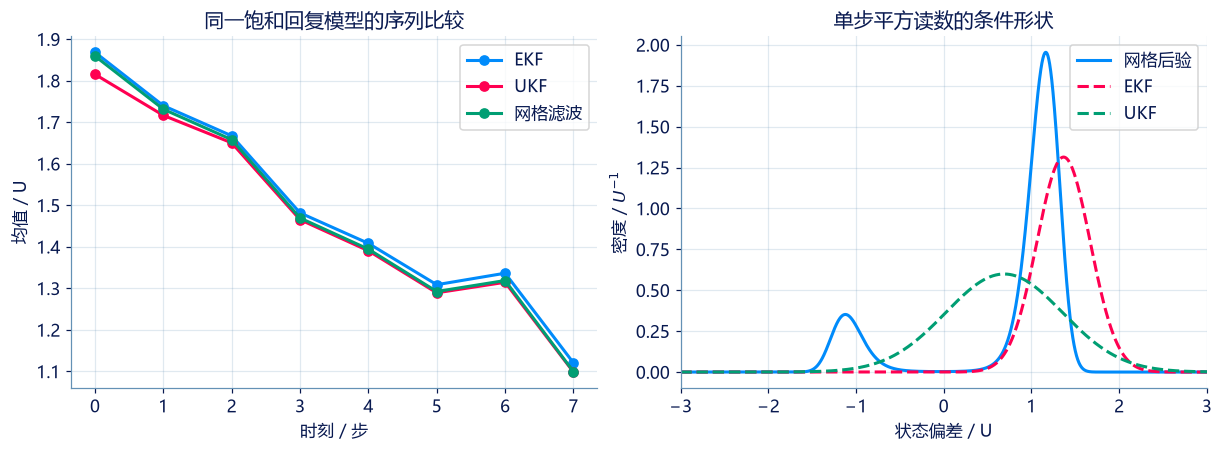

| 方法 | 后验均值/U | 方差/U² |
| --- | --- | --- |
| EKF | 1.36682 | 0.0921659 |
| UKF | 0.689233 | 0.443067 |
| 网格 | 0.766672 | 0.685303 |

In [4]:
observed=[3.5,3.0,2.8,2.1,2.0,1.7,1.9,1.1]
ekf=nonlinear_filter(1.8,.2,.04,.15,observed,'ekf');ukf=nonlinear_filter(1.8,.2,.04,.15,observed,'ukf');reference=grid_filter(1.8,.2,.04,.15,observed,count=801)
grid,density,gm,gp=grid_update(.6,.8,1.4,.15)
updates=[nonlinear_update(.6,.8,1.4,.15,method) for method in ['ekf','ukf']]
fig,axes=plt.subplots(1,2,figsize=(11,4))
for run,label in [(ekf,'EKF'),(ukf,'UKF'),(reference,'网格滤波')]:axes[0].plot(run['means'],marker='o',label=label)
axes[0].set(xlabel='时刻 / 步',ylabel='均值 / U',title='同一饱和回复模型的序列比较');axes[0].legend()
axes[1].plot(grid,density,label='网格后验')
for update,label in zip(updates,['EKF','UKF']):
    m,P=update['mean'],update['variance'];axes[1].plot(grid,np.exp(-(grid-m)**2/(2*P))/np.sqrt(2*np.pi*P),'--',label=label)
axes[1].set(xlim=(-3,3),xlabel='状态偏差 / U',ylabel='密度 / $U^{-1}$',title='单步平方读数的条件形状');axes[1].legend();plt.show()
display(Markdown(show_table(['方法','后验均值/U','方差/U²'],[[label,u['mean'],u['variance']] for label,u in zip(['EKF','UKF'],updates)]+[['网格',gm,gp]])))

### 独立核验与边界

In [5]:
u=nonlinear_update(.6,.8,1.4,.15,'ukf')
np.testing.assert_allclose([u['observation_mean'],u['innovation_variance'],u['cross_covariance']],[.6**2+.8,4*.6**2*.8+2*.8**2+.15,2*.6*.8])
fine=grid_filter(1.8,.2,.04,.15,observed,count=1201,limit=8.)
np.testing.assert_allclose(reference['means'],fine['means'],atol=2e-5)
np.testing.assert_allclose(reference['variances'],fine['variances'],atol=2e-5)
for a,b in [(2.,.3),(-1.,0.),(0.,2.)]:
    m=.4;P=.7;points=np.array([m,m+np.sqrt(P),m-np.sqrt(P)]);trans=a*points+b;ym=np.array([0,.5,.5])@trans
    np.testing.assert_allclose(ym,a*m+b);np.testing.assert_allclose(np.array([2,.5,.5])@(trans-ym)**2,a*a*P)
print('平方解析矩、线性退化、网格加密和扩大范围对照通过。')

平方解析矩、线性退化、网格加密和扩大范围对照通过。


## 结果解释

表和右图应同时阅读：两个近似都压缩为单个Gaussian，无法保持不对称双峰。左图比较共享模型和读数；结果不支持“UKF普遍更好”。改变初值（initial condition）、观测噪声与曲率后，主导误差可能不同。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：三个采样点传播平方观测

使用n=1、alpha=1、beta=2、kappa=0的无迹变换。输入（input）先验（prior）均值方差（variance），返回平方观测（observation）的预测均值、含噪方差与状态（state）-观测交叉协方差（covariance）。

**函数与代码模板**

```python
def solve(
    mean: float,
    variance: float,
    measurement_variance: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 状态先验均值。 | U |
| `variance` | `float` | 状态先验方差。 | U² |
| `measurement_variance` | `float` | 与状态独立的零均值加性观测噪声方差。 | U⁴ |

**返回值**

按以下顺序返回元组：(observation_mean, innovation_variance, cross_covariance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `observation_mean` | `float` | 平方观测的预测均值。 | U² |
| `innovation_variance` | `float` | 变换方差加噪声方差。 | U⁴ |
| `cross_covariance` | `float` | 状态与平方观测的交叉协方差。 | U³ |

**计算规则**

点为m、m+sqrt(P)、m−sqrt(P)。均值权重[0,0.5,0.5]，协方差权重[2,0.5,0.5]。用平方后的点计算均值、方差及与原点的交叉协方差，最后给方差加R。

**约束与边界**

- variance>0，measurement_variance>0；|mean|≤10，方差≤100。
- 不能把均值权重直接替代协方差权重。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| mean | 状态先验均值。 | 0.6 | U |
| variance | 状态先验方差。 | 0.8 | U² |
| measurement_variance | 与状态独立的零均值加性观测噪声方差。 | 0.15 | U⁴ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
mean = 0.6
variance = 0.8
measurement_variance = 0.15

result = solve(mean, variance, measurement_variance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| observation_mean | 平方观测的预测均值。 | 1.16 | U² |
| innovation_variance | 变换方差加噪声方差。 | 2.582 | U⁴ |
| cross_covariance | 状态与平方观测的交叉协方差。 | 0.96 | U³ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.16, 2.5819999999999994, 0.96)
```

**样例解释**

样例预测观测均值1.16，方差2.582，交叉协方差0.96；中心点的协方差权重为2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：三个采样点传播平方观测](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-unscented-moments)

### 第 2 题 · 多项选择题：均值权重与协方差权重

本节无迹变换参数（parameter）为n=1、alpha=1、beta=2、kappa=0。哪些正确？

- **A.** 中心点均值权重为0。
- **B.** 中心点协方差（covariance）权重也为0。
- **C.** 两侧点均值权重各为0.5。
- **D.** 协方差权重必须加和为1才合法。

[作答：均值权重与协方差权重](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-sigma-weights)

### 第 3 题 · 单项选择题：矩准确意味着后验准确吗

对高斯先验（prior）的平方观测（observation），本节UT可准确给出观测前均值、方差（variance）和交叉协方差（covariance）。哪项成立？

- **A.** 更新得到的高斯一定等于真实后验（posterior）。
- **B.** 观测前矩准确仍不保证条件后验为高斯。
- **C.** 单高斯可精确表示任意双峰。
- **D.** UKF对所有模型（model）都优于EKF。

[作答：矩准确意味着后验准确吗](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-moment-not-posterior)

### 第 4 题 · 多项选择题：网格参照也要核验

用[-6,6]上的6001点积分作为一维后验（posterior）参照。哪些检查必要？

- **A.** 加密网格，比较均值和方差（variance）变化。
- **B.** 扩大边界，检查截断影响。
- **C.** 画出曲线就证明积分完全精确。
- **D.** 按概率密度（probability density）乘网格尺度后归一化。

[作答：网格参照也要核验](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-grid-validation)

### 第 5 题 · 单项选择题：后验均值零是否没有更新

对称先验（prior）和平方观测（observation）下，精确后验（posterior）均值仍为0，但密度从单峰变成双峰。哪项正确？

- **A.** 分布（distribution）完全不变。
- **B.** 均值不足以描述变化，方差（variance）和形状仍可改变。
- **C.** 双峰证明采样（sampling）程序出错。
- **D.** 只需比较均值就能评判所有滤波器。

[作答：后验均值零是否没有更新](http://127.0.0.1:8000/chapters/07-04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%AB%98%E6%96%AF%E6%BB%A4%E6%B3%A2/practice/?question=p07-symmetric-posterior)

### 延伸阅读

R26，第8章Gaussian滤波与无迹矩近似。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-04-非线性高斯滤波/explore/) · [本篇目录](../README.md)